# Astlingen Rainfall 365-Day Climatological GMM Stratified Split & Experiment Version Tracking

This notebook implements direct **365-Day Day-of-Year (DOY) Climatological GMM/K-Means Clustering** and stratified time-series splitting for the **Astlingen Erft precipitation dataset** (2000–2009).

### Objectives
1. **Data Loading & 365-Day DOY Profile Extraction**: Load continuous 5-minute gauge telemetry, calculate 14-day rolling mean climatological profiles for Daily Total Rainfall (mm), Maximum 5-Min Intensity (mm), and Rainy Fraction across the 365 Days-of-Year ($DOY \in [1, 365]$).
2. **Modular 365-Day Experiment Pipeline**: Define a parameterized end-to-end pipeline supporting HMM seasonal feature integration (`HMM_STATES`), GMM component counts (`GMM_K`), and safe stratified splits.
3. **Side-by-Side HMM vs GMM Band Visualizations**: Plot predicted HMM seasonal states as background vertical bands on the left pane vs predicted GMM cluster regimes as background vertical bands on the right pane over 365-day smoothed profiles.
4. **Multi-Feature Model Selection ($K \in [1, 15]$)**: Evaluate BIC, AIC, Log-Likelihood, and Variational ELBO across No-HMM (3D), 4-State HMM (4D), and 5-State HMM (4D) representations with markers at $K=4$ and $K=5$.
5. **Multi-Experiment Version Tracking**: Run six target configurations in exact requested order:
   - **`doy365_nohmm_k4`**: No-HMM (3D physical), $K=4$ GMM.
   - **`doy365_nohmm_k5`**: No-HMM (3D physical), $K=5$ GMM.
   - **`doy365_hmm4_k4`**: 4 HMM states, $K=4$ GMM.
   - **`doy365_hmm4_k5`**: 4 HMM states, $K=5$ GMM.
   - **`doy365_hmm5_k4`**: 5 HMM states, $K=4$ GMM.
   - **`doy365_hmm5_k5`**: 5 HMM states, $K=5$ GMM.
6. **Version-Specific Subdirectory Exports**: Export version-tagged CSV datasets under `../data/rainfall/astlingen/splits/365day_climatological/{version}/`.
7. **UMAP & Feature Distribution Visualizations**: Render 365-day DOY time series overlays, 2D UMAP scatter projections, and 4-panel regime profile boxplots for all six experiment versions.


In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import umap

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from hmmlearn import hmm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
SEED = 42


## 1. Data Loading & 365-Day DOY Climatological Profile Extraction

We load 4 gauge CSV files from `../data/rainfall/astlingen/` and aggregate continuous 5-minute telemetry into 365 daily climatological profiles ($DOY \in [1, 365]$).


In [3]:
data_dir = Path("../data/rainfall/astlingen")
files = sorted(list(data_dir.glob("*Astlingen_Erft*.csv")))
if not files:
    raise FileNotFoundError(f"No Astlingen CSV files found in {data_dir}")

print(f"Found {len(files)} gauge files: {[f.name for f in files]}")
dfs = []
for f in files:
    df = pd.read_csv(f)
    df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"], format="%m/%d/%Y %H:%M:%S")
    df = df.set_index("datetime")
    val_col = [c for c in df.columns if c not in ["date", "time"]][0]
    gauge_id = f.stem
    dfs.append(df[[val_col]].rename(columns={val_col: gauge_id}))

df_merged = pd.concat(dfs, axis=1)
df_merged["avg_rainfall"] = df_merged.mean(axis=1)
df_full = df_merged.dropna(subset=["avg_rainfall"])
print(f"Merged continuous dataset shape: {df_full.shape}")

daily = pd.DataFrame({
    "Total Rainfall": df_full["avg_rainfall"].resample("D").sum(),
    "Maximum Intensity": df_full["avg_rainfall"].resample("D").max(),
    "Rainy Fraction": df_full["avg_rainfall"].resample("D").apply(lambda x: (x > 0).mean())
})
smoothed = daily.rolling(window=14, center=True).mean().dropna()
smoothed["doy"] = smoothed.index.dayofyear
profile_365 = smoothed.groupby("doy").mean()
if 366 in profile_365.index:
    profile_365 = profile_365.drop(index=366)
print(f"Extracted 365 DOY climatological profile shape: {profile_365.shape}")


Found 4 gauge files: ['1Astlingen_Erft1.csv', '2Astlingen_Erft2.csv', '3Astlingen_Erft3.csv', '4Astlingen_Erft4.csv']
Merged continuous dataset shape: (1051200, 5)
Extracted 365 DOY climatological profile shape: (365, 3)


## 2. Parameterized 365-Day Experiment & Dataset Versioning Pipeline

We define `run_365d_experiment_pipeline()` to execute HMM feature fitting, 365 DOY regime clustering, mapping DOY labels to continuous telemetry, safe stratified splitting, and exports to version-specific subdirectories.


In [5]:
def safe_stratified_split(df, stratify_col, test_size=0.2, random_state=42):
    """Performs stratified train_test_split, allocating rare singleton classes (<2 items) directly to train."""
    counts = df[stratify_col].value_counts()
    rare_classes = counts[counts < 2].index
    df_rare = df[df[stratify_col].isin(rare_classes)]
    df_regular = df[~df[stratify_col].isin(rare_classes)]
    
    if len(df_regular) > 0:
        df_train_reg, df_test_reg = train_test_split(
            df_regular, test_size=test_size, stratify=df_regular[stratify_col], random_state=random_state
        )
        df_train = pd.concat([df_train_reg, df_rare])
        df_test = df_test_reg
    else:
        df_train = df
        df_test = pd.DataFrame()
    return df_train, df_test

def run_365d_experiment_pipeline(df_full, profile_365, hmm_states, gmm_k, seed=42, export_prefix="doy365_nohmm_k4"):
    df_doy = profile_365.copy().reset_index()
    
    use_hmm = (hmm_states > 0)
    if use_hmm:
        scaler_hmm = StandardScaler()
        X_hmm = scaler_hmm.fit_transform(df_doy[["Total Rainfall", "Maximum Intensity", "Rainy Fraction"]])
        model_hmm = hmm.GaussianHMM(n_components=hmm_states, covariance_type="full", n_iter=2000, random_state=seed)
        model_hmm.fit(X_hmm)
        df_doy["season"] = model_hmm.predict(X_hmm)

    features = ["Total Rainfall", "Maximum Intensity", "Rainy Fraction"]
    if use_hmm:
        features.append("season")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_doy[features])

    gmm = GaussianMixture(n_components=gmm_k, covariance_type="full", random_state=seed)
    df_doy["gmm_regime"] = gmm.fit_predict(X_scaled)

    kmeans = KMeans(n_clusters=gmm_k, random_state=seed)
    df_doy["stratum"] = kmeans.fit_predict(X_scaled)

    sil_gmm = silhouette_score(X_scaled, df_doy["gmm_regime"])
    db_gmm = davies_bouldin_score(X_scaled, df_doy["gmm_regime"])
    sil_kmeans = silhouette_score(X_scaled, df_doy["stratum"])
    db_kmeans = davies_bouldin_score(X_scaled, df_doy["stratum"])

    # Map DOY regime back to continuous daily telemetry series
    df_daily_full = pd.DataFrame({
        "avg_rainfall": df_full["avg_rainfall"].resample("D").mean()
    })
    df_daily_full["doy"] = df_daily_full.index.dayofyear
    doy_to_regime = dict(zip(df_doy["doy"], df_doy["gmm_regime"]))
    df_daily_full["gmm_regime"] = df_daily_full["doy"].map(lambda d: doy_to_regime.get(d, doy_to_regime.get(365, 0)))

    df_train_daily, df_temp_daily = safe_stratified_split(df_daily_full.reset_index(), "gmm_regime", test_size=0.2, random_state=seed)
    df_val_daily, df_test_daily = safe_stratified_split(df_temp_daily, "gmm_regime", test_size=0.5, random_state=seed)

    train_dates = set(df_train_daily["datetime"])
    val_dates = set(df_val_daily["datetime"])
    test_dates = set(df_test_daily["datetime"])

    df_5min = df_full.copy()
    df_5min["date_only"] = pd.to_datetime(df_5min.index.date)
    
    df_train_5min = df_5min[df_5min["date_only"].isin(train_dates)].drop(columns=["date_only"])
    df_val_5min = df_5min[df_5min["date_only"].isin(val_dates)].drop(columns=["date_only"])
    df_test_5min = df_5min[df_5min["date_only"].isin(test_dates)].drop(columns=["date_only"])

    df_train_5min["split_label"] = "train"
    df_val_5min["split_label"] = "val"
    df_test_5min["split_label"] = "test"

    version_dir = Path(f"../data/rainfall/astlingen/splits/365day_climatological/{export_prefix}")
    version_dir.mkdir(parents=True, exist_ok=True)
    
    profiles_path = version_dir / f"astlingen_doy365_profiles_{export_prefix}.csv"
    df_doy.to_csv(profiles_path, index=False)

    train_path = version_dir / f"train_{export_prefix}.csv"
    val_path = version_dir / f"val_{export_prefix}.csv"
    test_path = version_dir / f"test_{export_prefix}.csv"

    df_train_5min.to_csv(train_path)
    df_val_5min.to_csv(val_path)
    df_test_5min.to_csv(test_path)

    return {
        "version": export_prefix,
        "hmm_states": hmm_states if use_hmm else "None (3D)",
        "gmm_k": gmm_k,
        "sil_gmm": sil_gmm,
        "db_gmm": db_gmm,
        "sil_kmeans": sil_kmeans,
        "db_kmeans": db_kmeans,
        "train_rows": len(df_train_5min),
        "val_rows": len(df_val_5min),
        "test_rows": len(df_test_5min),
        "df_profiles": df_doy,
        "X_scaled": X_scaled,
        "gmm": gmm,
        "profiles_path": str(profiles_path),
        "train_path": str(train_path),
        "val_path": str(val_path),
        "test_path": str(test_path)
    }

print("run_365d_experiment_pipeline() defined successfully!")


run_365d_experiment_pipeline() defined successfully!


### 2.1 Side-by-Side Comparison: HMM Seasonal Bands vs Direct GMM Physical Bands (365 DOY)

**Understanding Model Differences**:
- **Left Pane (HMM Seasonal States)**: Gaussian HMM incorporates **sequential temporal Markov transitions** ($S_t \rightarrow S_{t+1}$), producing contiguous, smooth seasonal state transitions across DOY $1 \dots 365$.
- **Right Pane (Direct GMM Physical Regimes)**: GMM fit directly on 3D physical features (`[Total Rainfall, Maximum Intensity, Rainy Fraction]`) clusters data points independently based solely on feature space density without temporal continuity constraints.
- **Note on 4D HMM-Feature Experiments**: When GMM is fit on 4D features including HMM `season` (`doy365_hmm4_k4`, etc.), the discrete `season` feature forms strong distinct modes in 4D space, causing GMM clusters to align 1-to-1 with HMM states.


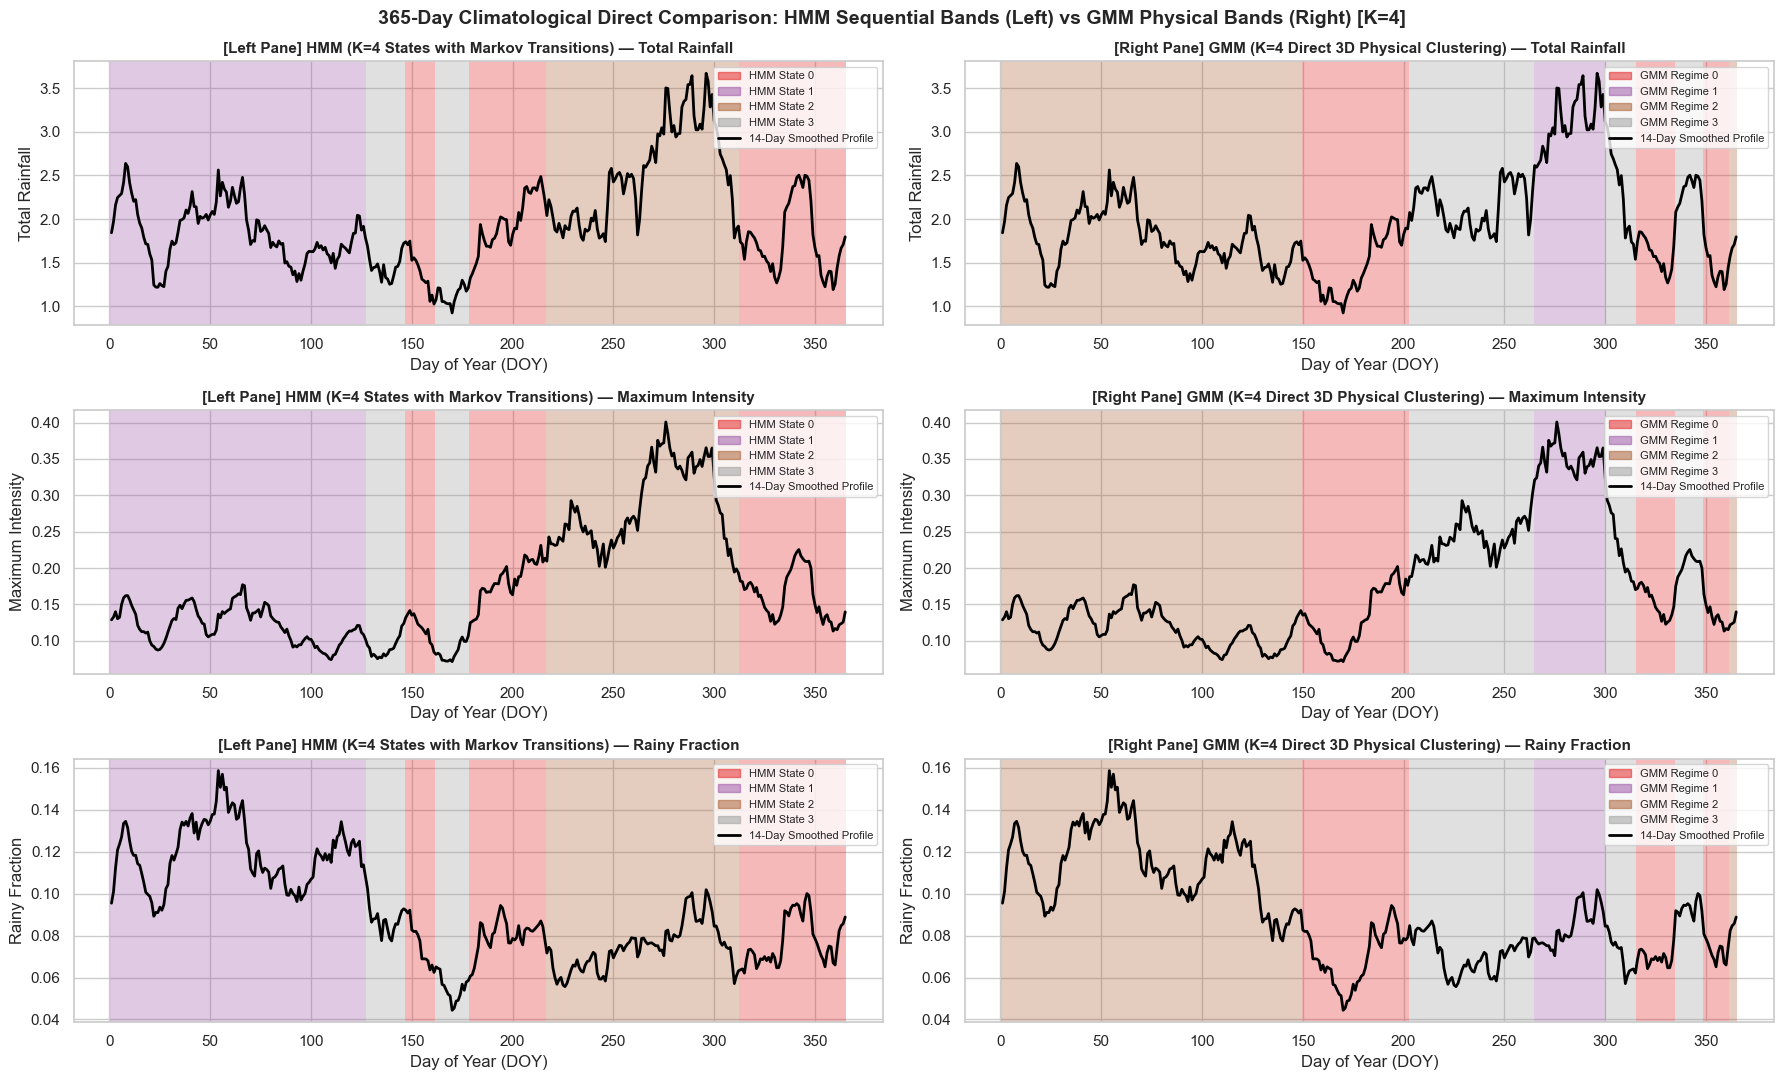

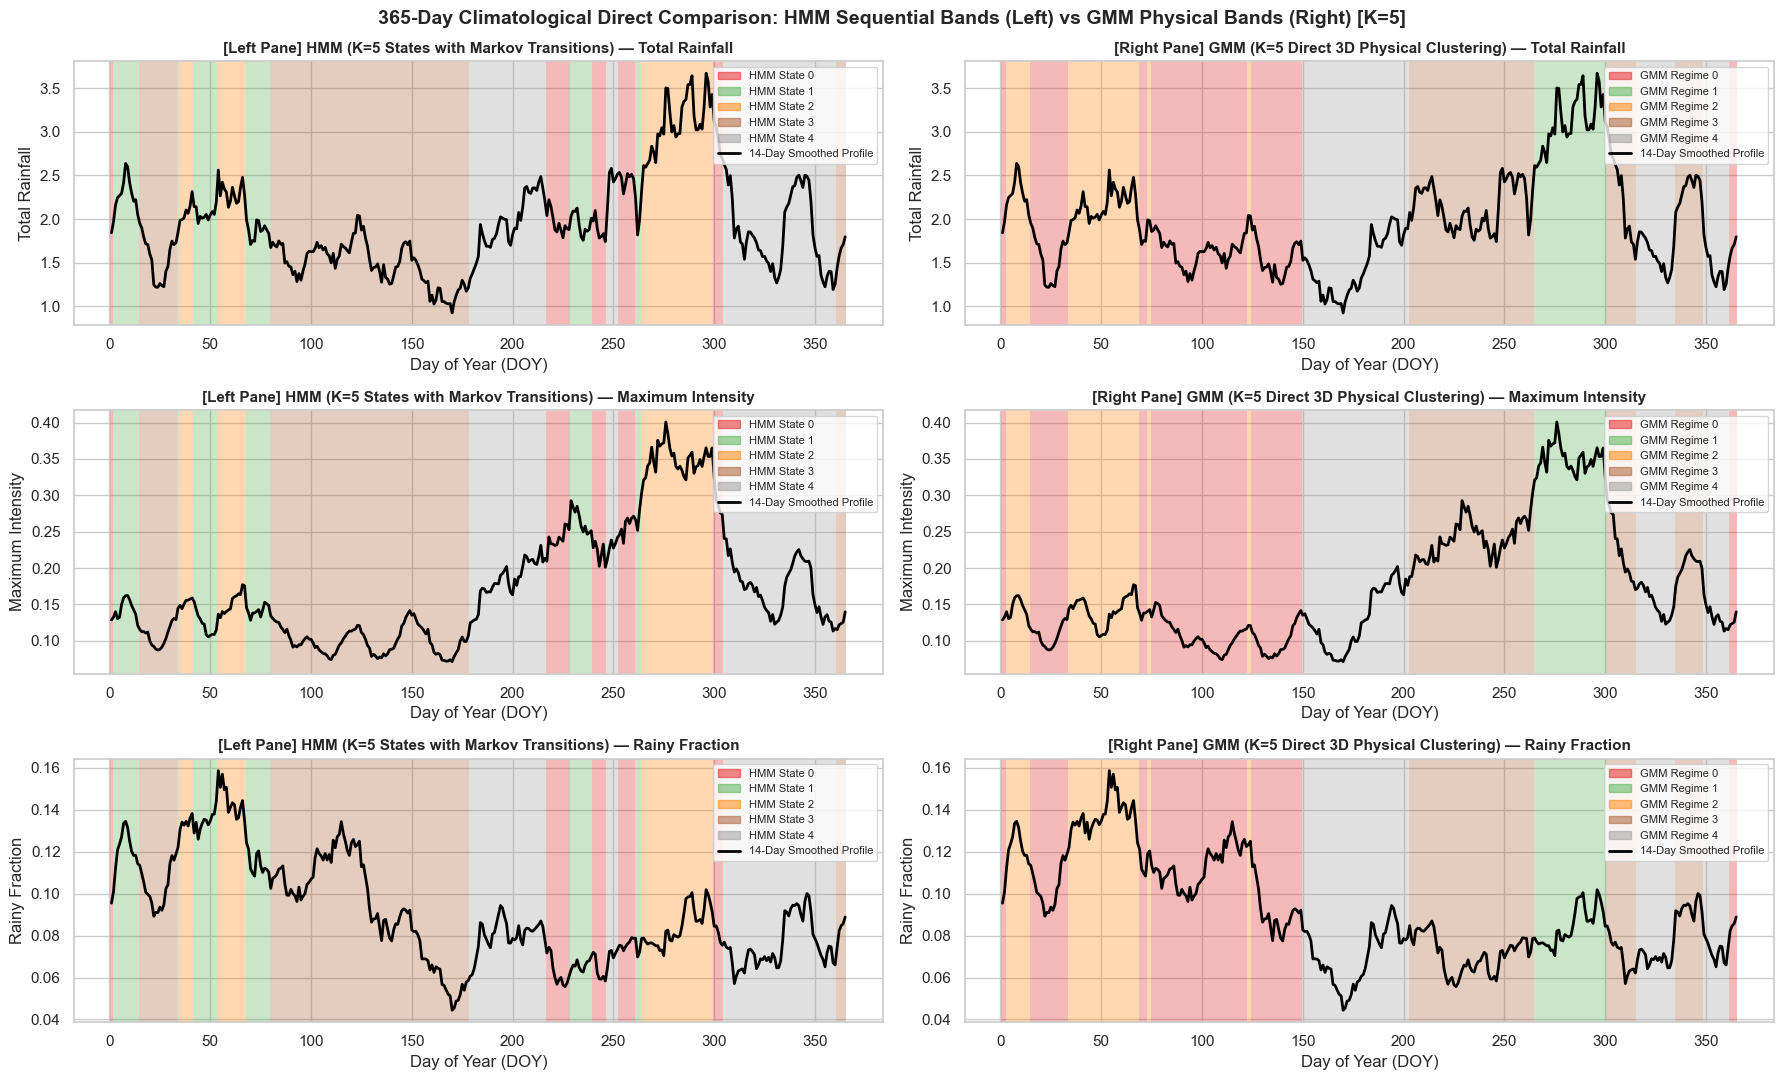

In [7]:
X_3d_physical = StandardScaler().fit_transform(profile_365[["Total Rainfall", "Maximum Intensity", "Rainy Fraction"]])

doys_b = profile_365.index.values
metrics_b = ["Total Rainfall", "Maximum Intensity", "Rainy Fraction"]
cmap_b = plt.colormaps.get_cmap("Set1")

def draw_state_bands(ax, doys, states, n_states, label_prefix="State"):
    colors = [cmap_b(i / max(n_states - 1, 1)) for i in range(n_states)]
    start_idx = 0
    for i in range(1, len(states)):
        if states[i] != states[start_idx]:
            ax.axvspan(doys[start_idx] - 0.5, doys[i - 1] + 0.5, color=colors[int(states[start_idx])], alpha=0.3, lw=0)
            start_idx = i
    ax.axvspan(doys[start_idx] - 0.5, doys[-1] + 0.5, color=colors[int(states[start_idx])], alpha=0.3, lw=0)
    patches = [mpatches.Patch(color=colors[i], alpha=0.5, label=f"{label_prefix} {i}") for i in range(n_states)]
    return patches

for target_k in [4, 5]:
    # 1) Fit HMM with target_k states
    model_h = hmm.GaussianHMM(n_components=target_k, covariance_type="full", n_iter=2000, random_state=SEED)
    model_h.fit(X_3d_physical)
    hmm_states = model_h.predict(X_3d_physical)

    # 2) Fit direct GMM with target_k regimes on 3D physical metrics directly
    gmm_3d = GaussianMixture(n_components=target_k, covariance_type="full", random_state=SEED)
    gmm_regimes_3d = gmm_3d.fit_predict(X_3d_physical)

    fig, axes = plt.subplots(3, 2, figsize=(18, 11))
    fig.suptitle(f"365-Day Climatological Direct Comparison: HMM Sequential Bands (Left) vs GMM Physical Bands (Right) [K={target_k}]", fontsize=14, fontweight="bold")
    
    for m_idx, col in enumerate(metrics_b):
        y_vals = profile_365[col].values
        
        # Left pane: HMM Bands (Sequential transition model)
        ax_left = axes[m_idx, 0]
        ax_left.plot(doys_b, y_vals, color="black", linewidth=2.0, label="14-Day Smoothed Profile")
        patches_h = draw_state_bands(ax_left, doys_b, hmm_states, target_k, "HMM State")
        ax_left.set_title(f"[Left Pane] HMM (K={target_k} States with Markov Transitions) — {col}", fontsize=11, fontweight="bold")
        ax_left.legend(handles=patches_h + [ax_left.get_lines()[0]], loc="upper right", fontsize=8)
        ax_left.set_xlabel("Day of Year (DOY)")
        ax_left.set_ylabel(col)

        # Right pane: Direct GMM Bands (Independent 3D physical clustering)
        ax_right = axes[m_idx, 1]
        ax_right.plot(doys_b, y_vals, color="black", linewidth=2.0, label="14-Day Smoothed Profile")
        patches_g = draw_state_bands(ax_right, doys_b, gmm_regimes_3d, target_k, "GMM Regime")
        ax_right.set_title(f"[Right Pane] GMM (K={target_k} Direct 3D Physical Clustering) — {col}", fontsize=11, fontweight="bold")
        ax_right.set_xlabel("Day of Year (DOY)")
        ax_right.set_ylabel(col)
        ax_right.legend(handles=patches_g + [ax_right.get_lines()[0]], loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()


## 3. Extended Model Selection ($K \in [1, 15]$) Across All 365 DOY Feature Representations

We evaluate component counts $K \in [1, 15]$ across **all three 365 DOY feature representations**, highlighting markers for $K=4$ (dotted gray) and $K=5$ (dashed green):
1. **No-HMM (3D)**: `[Total Rainfall, Maximum Intensity, Rainy Fraction]`
2. **4-State HMM (4D)**: `[Total Rainfall, Maximum Intensity, Rainy Fraction, season_hmm4]`
3. **5-State HMM (4D)**: `[Total Rainfall, Maximum Intensity, Rainy Fraction, season_hmm5]`


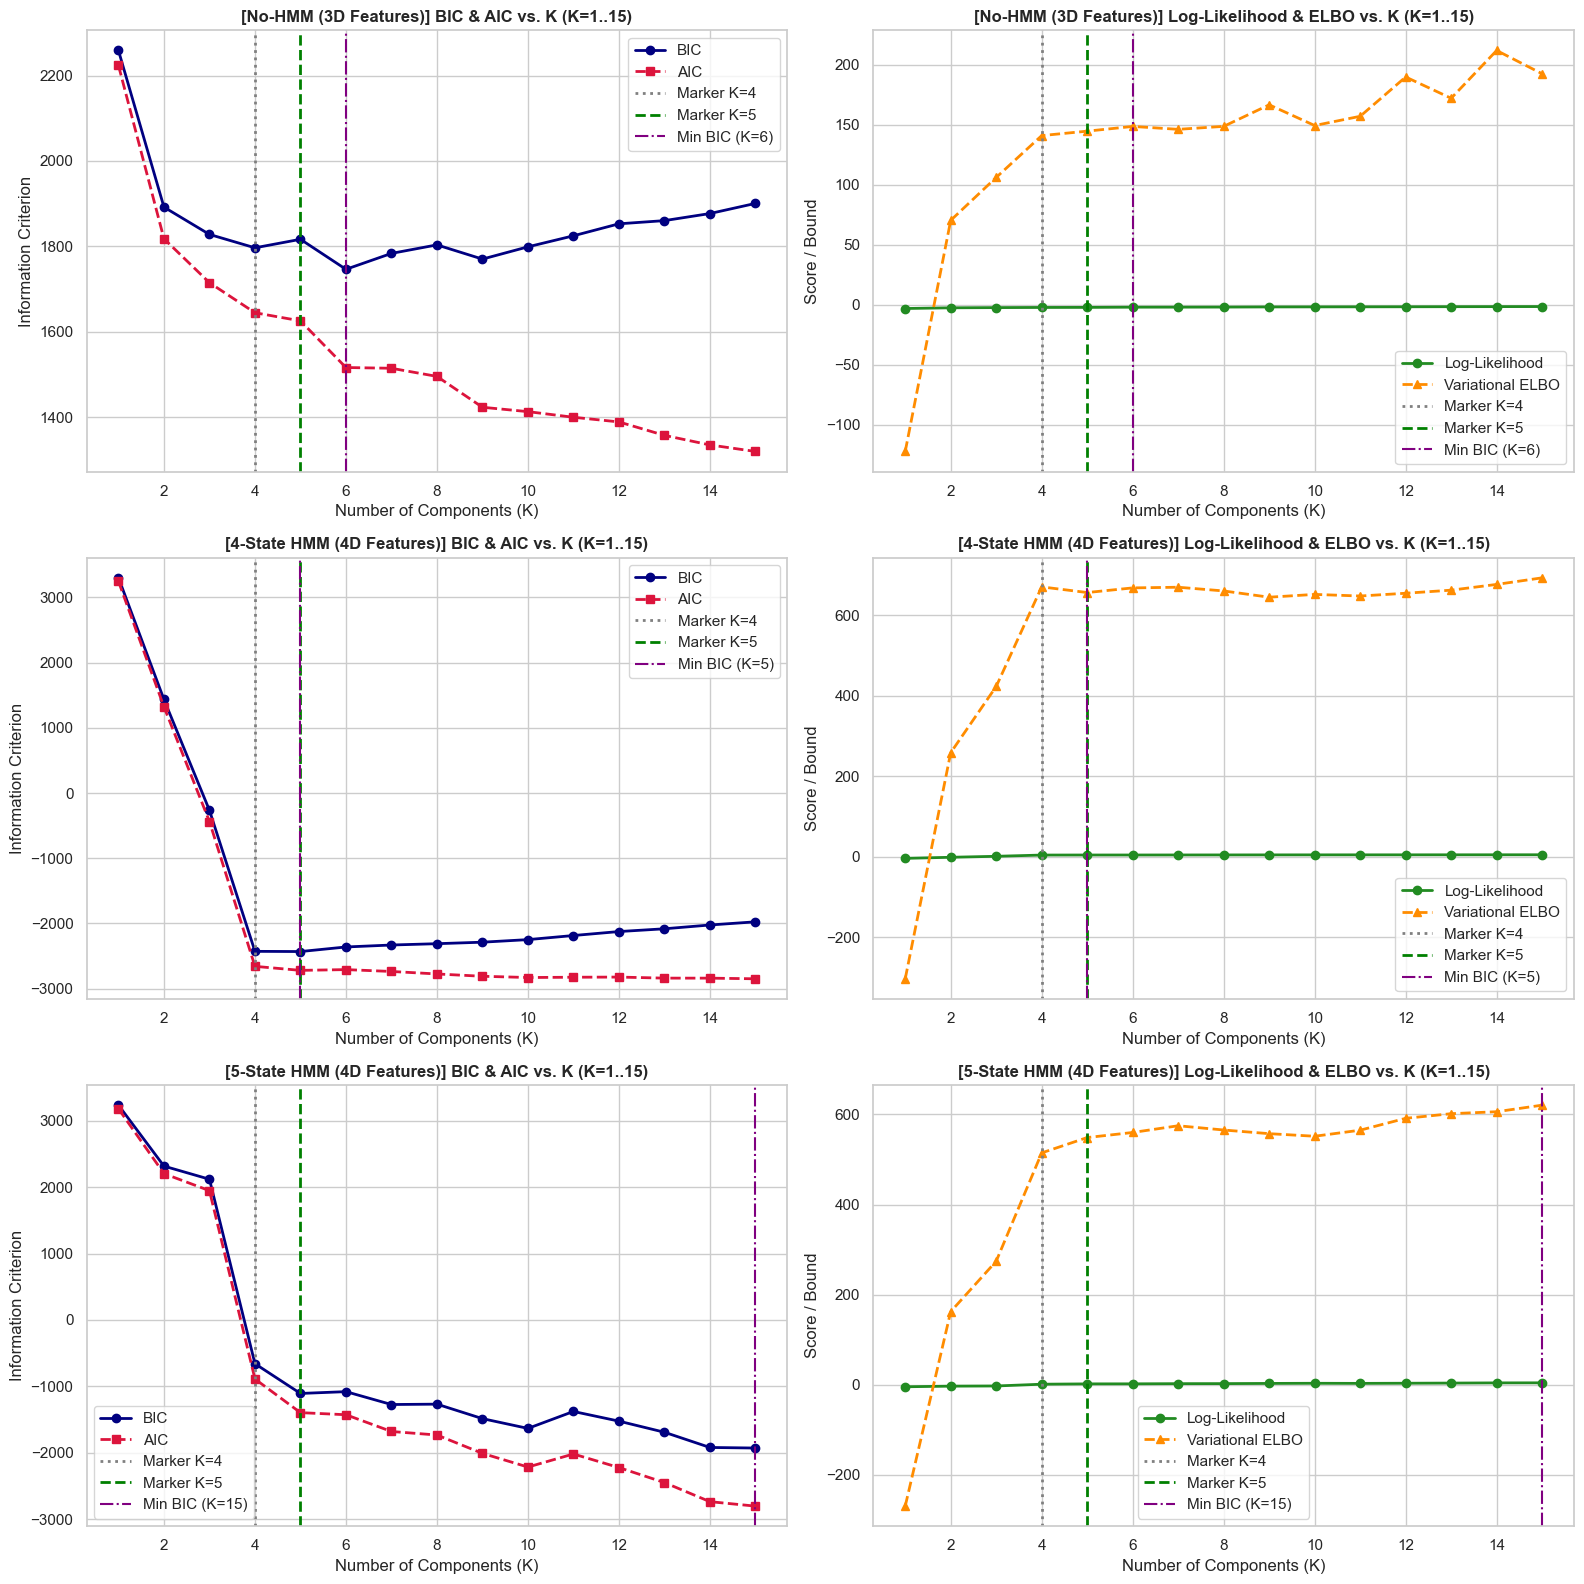

In [9]:
feature_configs = [
    ("No-HMM (3D Features)", 0, "doy365_nohmm_k4"),
    ("4-State HMM (4D Features)", 4, "doy365_hmm4_k4"),
    ("5-State HMM (4D Features)", 5, "doy365_hmm5_k4")
]

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
k_range = range(1, 16)

for idx, (label_name, h_states, pref) in enumerate(feature_configs):
    res_f = run_365d_experiment_pipeline(df_full, profile_365, h_states, 4, seed=SEED, export_prefix=pref)
    X_sc = res_f["X_scaled"]
    
    bics, aics, log_liks, elbos, sils = [], [], [], [], []
    for k in k_range:
        gmm_k = GaussianMixture(n_components=k, covariance_type="full", random_state=SEED, n_init=5)
        gmm_k.fit(X_sc)
        bics.append(gmm_k.bic(X_sc))
        aics.append(gmm_k.aic(X_sc))
        log_liks.append(gmm_k.score(X_sc))
        
        bgmm_k = BayesianGaussianMixture(
            n_components=k, covariance_type="full",
            weight_concentration_prior_type="dirichlet_process",
            random_state=SEED, n_init=5
        )
        bgmm_k.fit(X_sc)
        elbos.append(bgmm_k.lower_bound_)
        
        if k >= 2:
            sils.append(silhouette_score(X_sc, gmm_k.predict(X_sc)))
        else:
            sils.append(np.nan)
            
    min_bic_k = k_range[int(np.argmin(bics))]
    
    # Left plot: BIC & AIC
    axes[idx, 0].plot(k_range, bics, "o-", color="navy", linewidth=2, label="BIC")
    axes[idx, 0].plot(k_range, aics, "s--", color="crimson", linewidth=2, label="AIC")
    axes[idx, 0].axvline(x=4, color="gray", linestyle=":", linewidth=2, label="Marker K=4")
    axes[idx, 0].axvline(x=5, color="green", linestyle="--", linewidth=2, label="Marker K=5")
    axes[idx, 0].axvline(x=min_bic_k, color="purple", linestyle="-.", label=f"Min BIC (K={min_bic_k})")
    axes[idx, 0].set_title(f"[{label_name}] BIC & AIC vs. K (K=1..15)", fontsize=12, fontweight="bold")
    axes[idx, 0].set_xlabel("Number of Components (K)")
    axes[idx, 0].set_ylabel("Information Criterion")
    axes[idx, 0].legend()
    
    # Right plot: Log-Likelihood & Variational ELBO
    axes[idx, 1].plot(k_range, log_liks, "o-", color="forestgreen", linewidth=2, label="Log-Likelihood")
    axes[idx, 1].plot(k_range, elbos, "^--", color="darkorange", linewidth=2, label="Variational ELBO")
    axes[idx, 1].axvline(x=4, color="gray", linestyle=":", linewidth=2, label="Marker K=4")
    axes[idx, 1].axvline(x=5, color="green", linestyle="--", linewidth=2, label="Marker K=5")
    axes[idx, 1].axvline(x=min_bic_k, color="purple", linestyle="-.", label=f"Min BIC (K={min_bic_k})")
    axes[idx, 1].set_title(f"[{label_name}] Log-Likelihood & ELBO vs. K (K=1..15)", fontsize=12, fontweight="bold")
    axes[idx, 1].set_xlabel("Number of Components (K)")
    axes[idx, 1].set_ylabel("Score / Bound")
    axes[idx, 1].legend()

plt.tight_layout()
plt.show()


## 4. Multi-Experiment Execution & Version Tracking Summary (6 Configurations)

We execute the 365 DOY pipeline across six target configurations in exact requested order:
1. **`doy365_nohmm_k4`**: No-HMM (3D physical), 4 GMM regimes.
2. **`doy365_nohmm_k5`**: No-HMM (3D physical), 5 GMM regimes.
3. **`doy365_hmm4_k4`**: 4 HMM states, 4 GMM regimes.
4. **`doy365_hmm4_k5`**: 4 HMM states, 5 GMM regimes.
5. **`doy365_hmm5_k4`**: 5 HMM states, 4 GMM regimes.
6. **`doy365_hmm5_k5`**: 5 HMM states, 5 GMM regimes.


In [11]:
experiments = [
    ("doy365_nohmm_k4", 0, 4),
    ("doy365_nohmm_k5", 0, 5),
    ("doy365_hmm4_k4", 4, 4),
    ("doy365_hmm4_k5", 4, 5),
    ("doy365_hmm5_k4", 5, 4),
    ("doy365_hmm5_k5", 5, 5)
]

exp_results = {}
summary_rows = []

for prefix, h_states, g_k in experiments:
    res = run_365d_experiment_pipeline(df_full, profile_365, h_states, g_k, seed=SEED, export_prefix=prefix)
    exp_results[prefix] = res
    summary_rows.append({
        "Version Tag": res["version"],
        "HMM States": res["hmm_states"],
        "GMM K": res["gmm_k"],
        "GMM Silhouette": f"{res['sil_gmm']:.3f}",
        "GMM Davies-Bouldin": f"{res['db_gmm']:.3f}",
        "KMeans Silhouette": f"{res['sil_kmeans']:.3f}",
        "KMeans Davies-Bouldin": f"{res['db_kmeans']:.3f}",
        "Train Rows": res["train_rows"],
        "Val Rows": res["val_rows"],
        "Test Rows": res["test_rows"],
        "Profiles CSV": res["profiles_path"]
    })

summary_df = pd.DataFrame(summary_rows)
print("=== 365-DAY CLIMATOLOGICAL EXPERIMENT COMPARISON & VERSION TRACKING SUMMARY ===")
print(summary_df.to_string(index=False))


=== 365-DAY CLIMATOLOGICAL EXPERIMENT COMPARISON & VERSION TRACKING SUMMARY ===
    Version Tag HMM States  GMM K GMM Silhouette GMM Davies-Bouldin KMeans Silhouette KMeans Davies-Bouldin  Train Rows  Val Rows  Test Rows                                                                                                          Profiles CSV
doy365_nohmm_k4  None (3D)      4          0.393              0.786             0.471                 0.715      840672    105120     105408 ../data/rainfall/astlingen/splits/365day_climatological/doy365_nohmm_k4/astlingen_doy365_profiles_doy365_nohmm_k4.csv
doy365_nohmm_k5  None (3D)      5          0.397              0.803             0.439                 0.710      840960    104832     105408 ../data/rainfall/astlingen/splits/365day_climatological/doy365_nohmm_k5/astlingen_doy365_profiles_doy365_nohmm_k5.csv
 doy365_hmm4_k4          4      4          0.521              0.714             0.517                 0.719      840672    105120     105408   

## 5. UMAP Latent Space Clustering Visualizations (All 6 Experiment Versions)

For each of the six 365-day experiment versions, we project DOY features to 2D UMAP space and compare K-Means vs GMM boundaries.


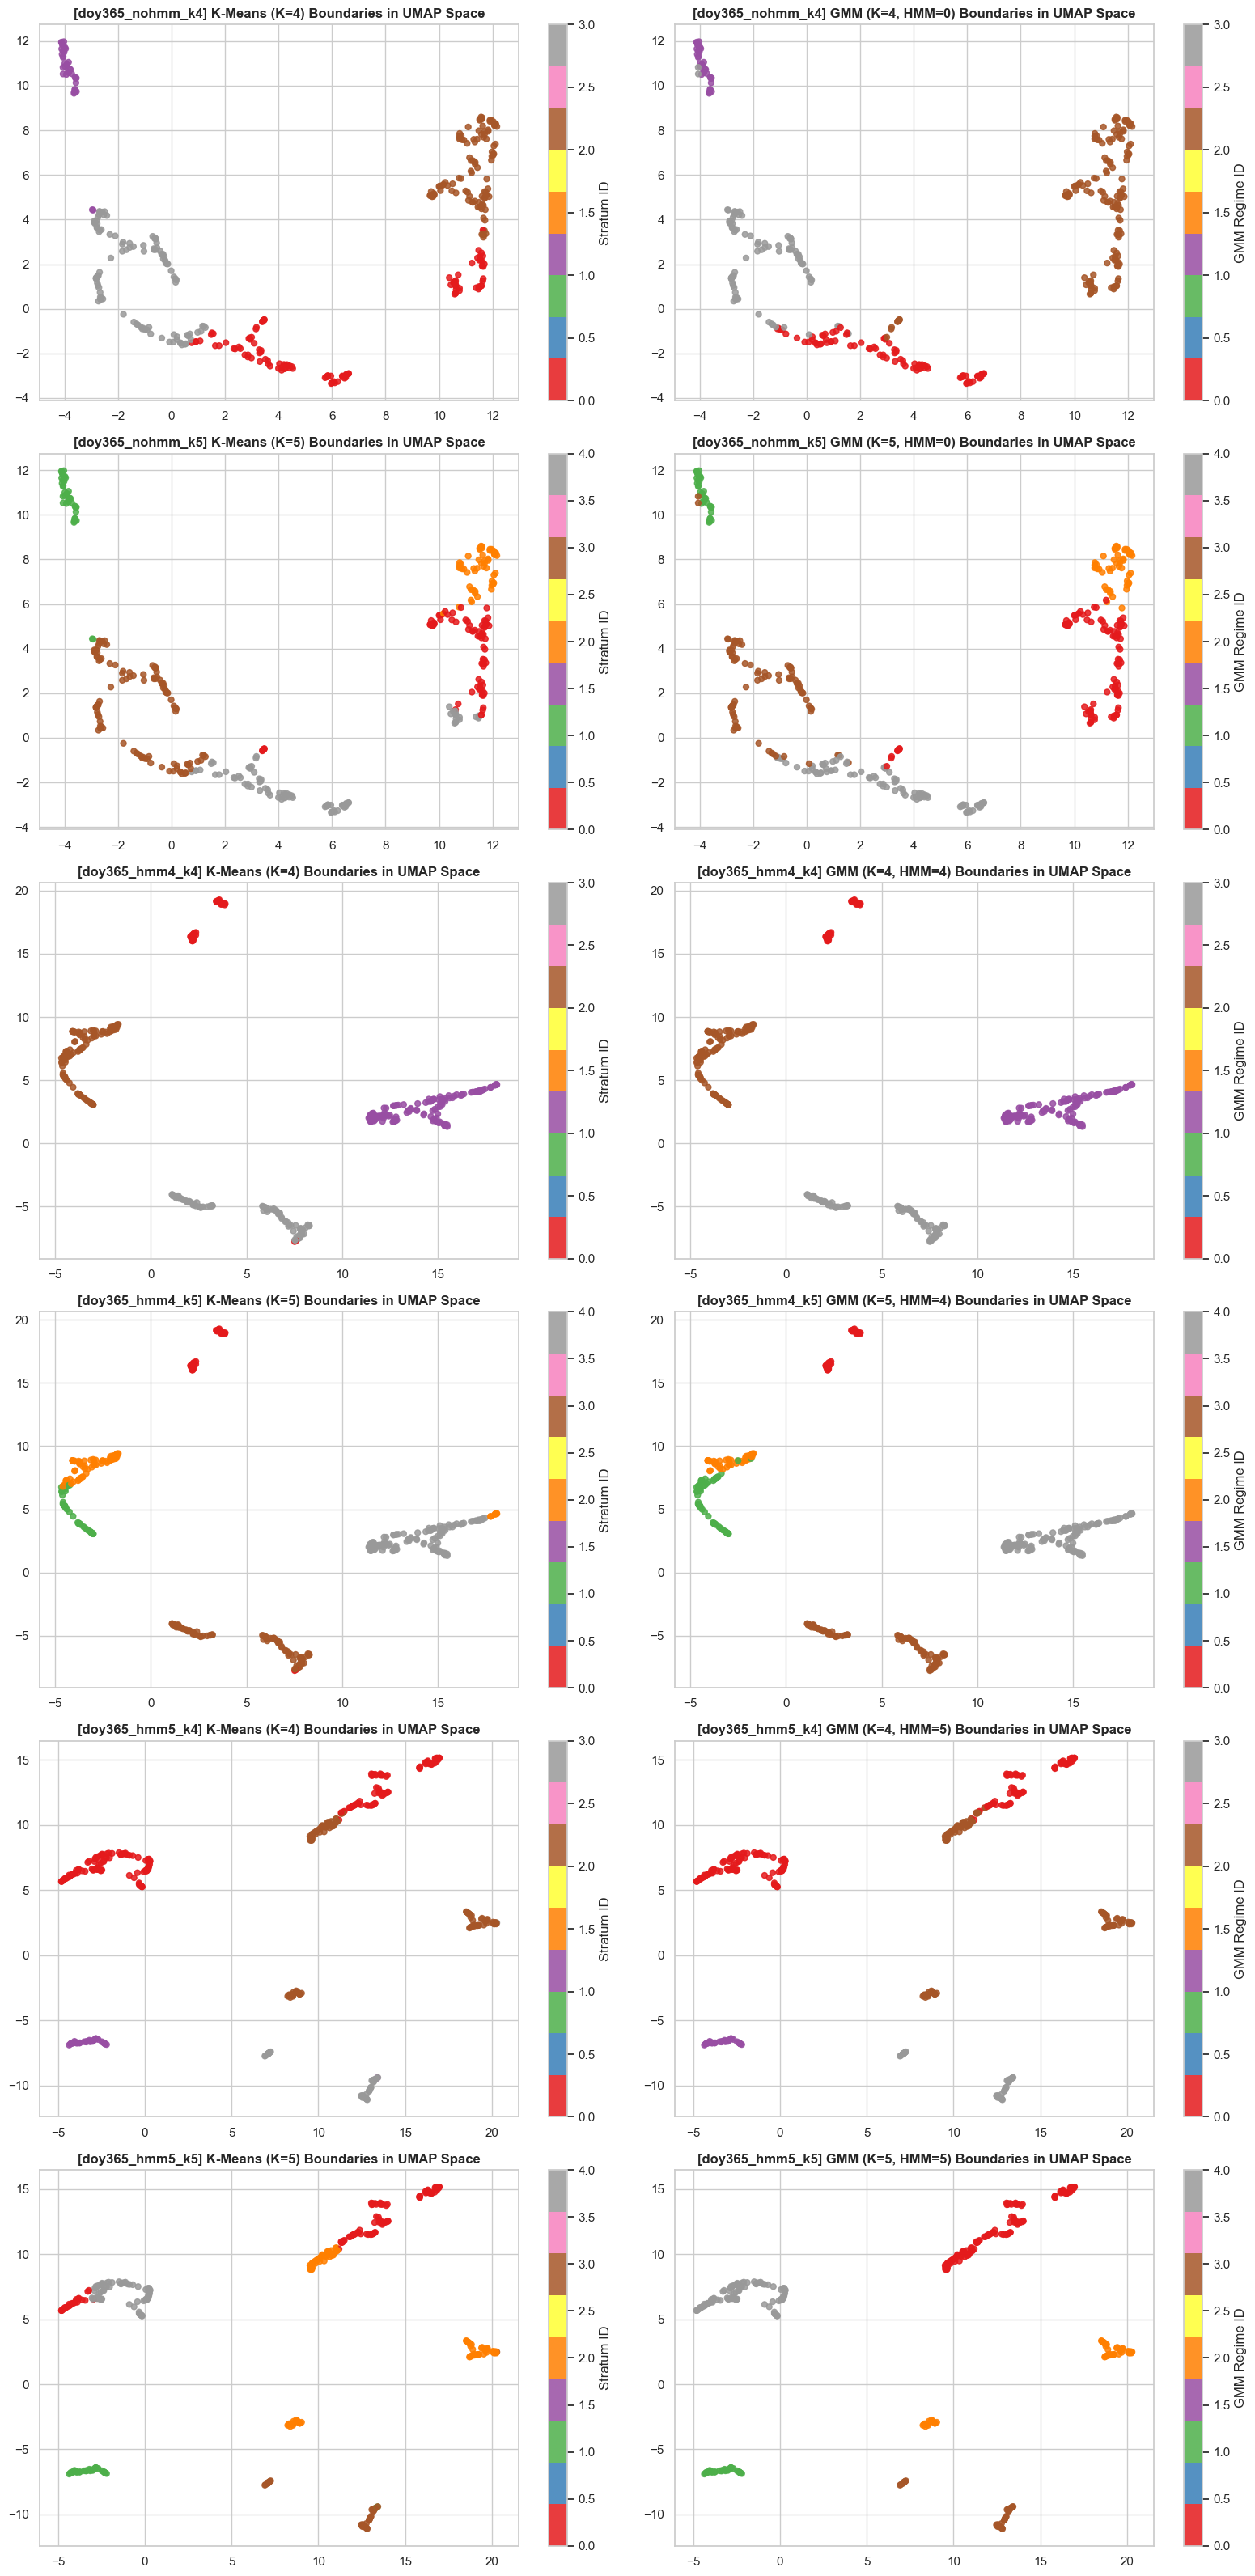

In [13]:
fig, axes = plt.subplots(6, 2, figsize=(16, 32))

for idx, (prefix, h_states, g_k) in enumerate(experiments):
    res = exp_results[prefix]
    X_sc = res["X_scaled"]
    df_p = res["df_profiles"]
    
    reducer = umap.UMAP(random_state=SEED, n_neighbors=15, min_dist=0.1)
    embedding = reducer.fit_transform(X_sc)
    
    sc1 = axes[idx, 0].scatter(embedding[:, 0], embedding[:, 1], c=df_p["stratum"], cmap="Set1", s=25, alpha=0.85)
    axes[idx, 0].set_title(f"[{prefix}] K-Means (K={g_k}) Boundaries in UMAP Space", fontsize=12, fontweight="bold")
    plt.colorbar(sc1, ax=axes[idx, 0], label="Stratum ID")
    
    sc2 = axes[idx, 1].scatter(embedding[:, 0], embedding[:, 1], c=df_p["gmm_regime"], cmap="Set1", s=25, alpha=0.85)
    axes[idx, 1].set_title(f"[{prefix}] GMM (K={g_k}, HMM={h_states}) Boundaries in UMAP Space", fontsize=12, fontweight="bold")
    plt.colorbar(sc2, ax=axes[idx, 1], label="GMM Regime ID")

plt.tight_layout()
plt.show()


## 6. Comprehensive Regime Profiling & Feature Boxplots (All 6 Experiment Versions)

Below we render 4-panel feature distribution boxplots for all six 365-day experiment versions.


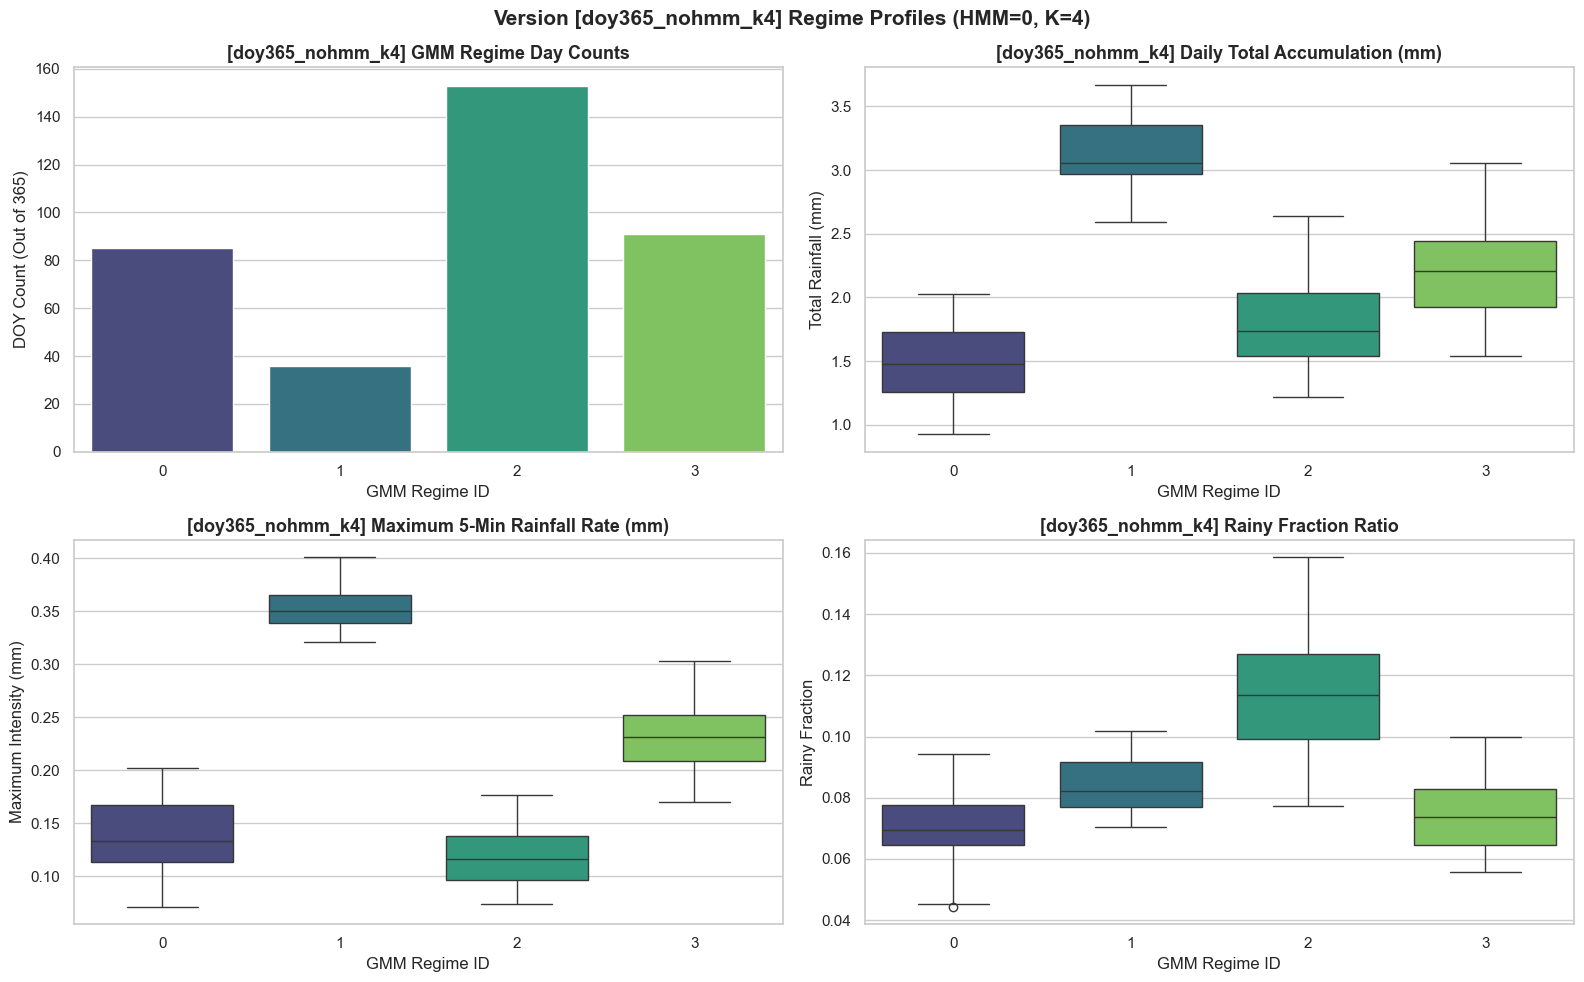

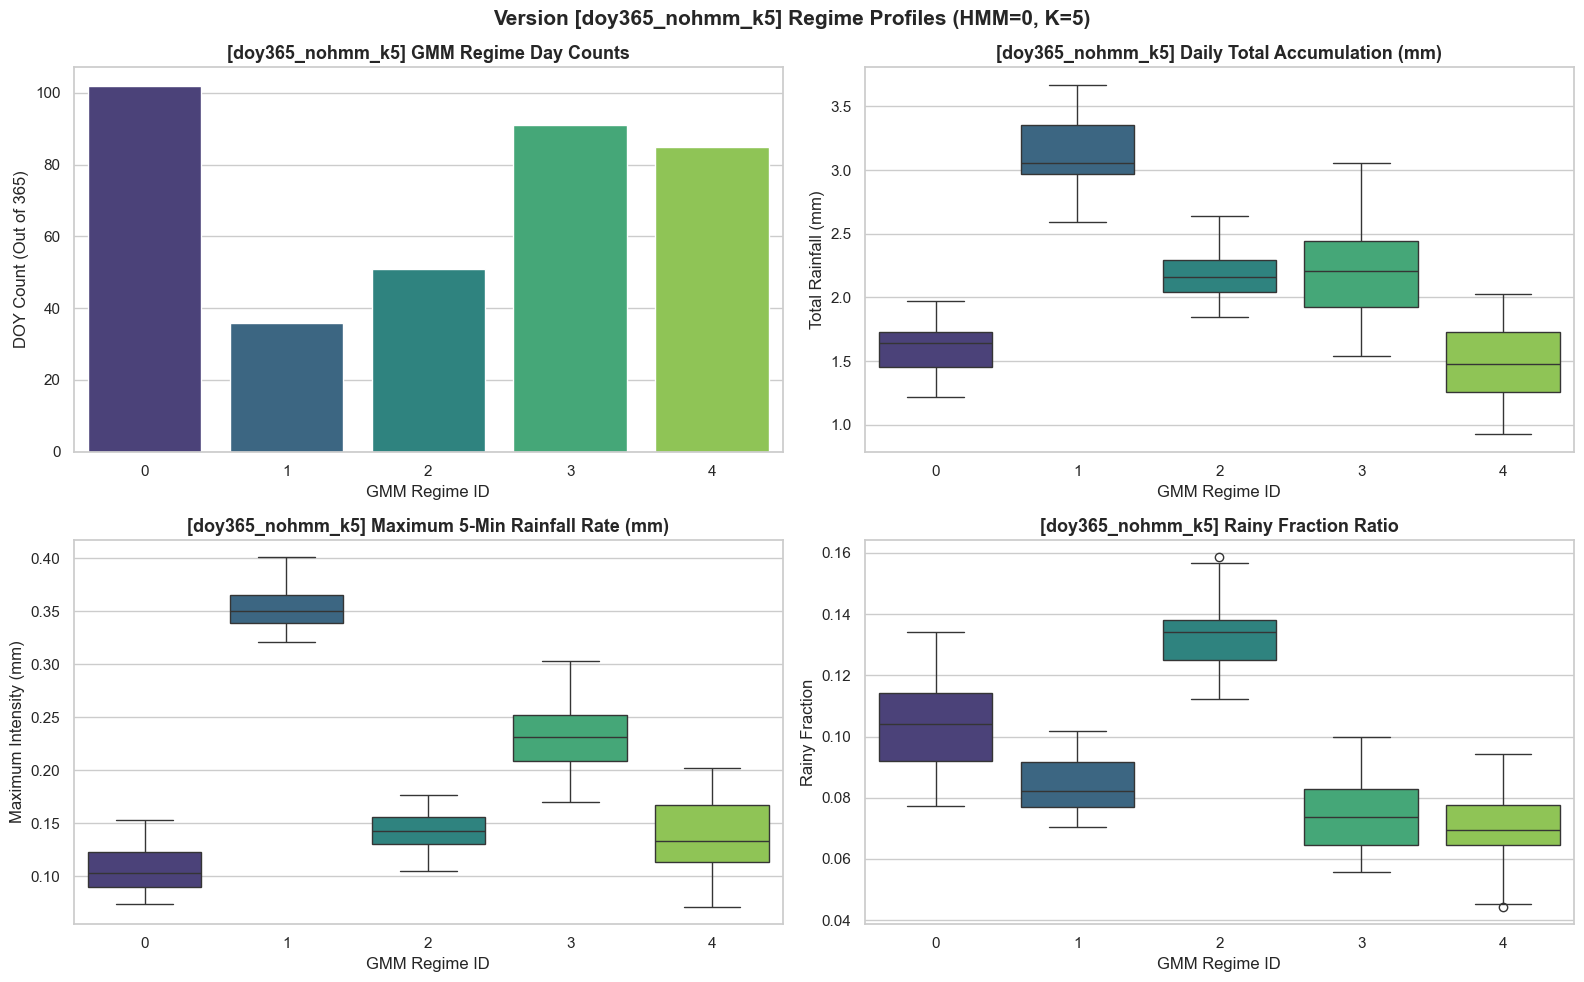

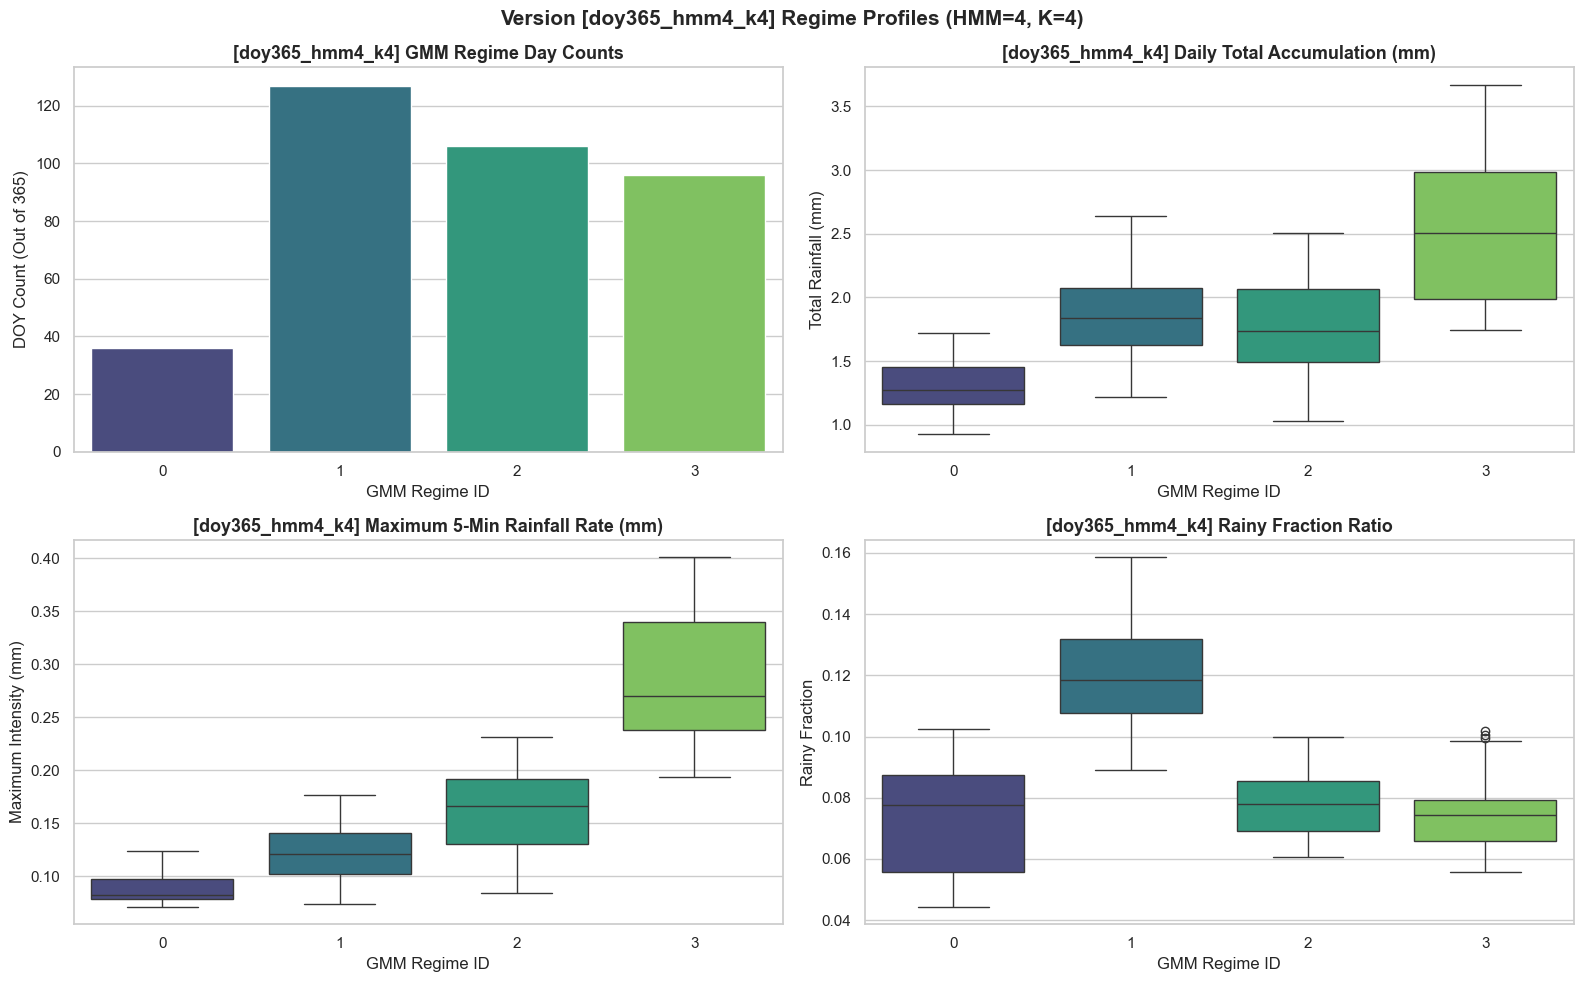

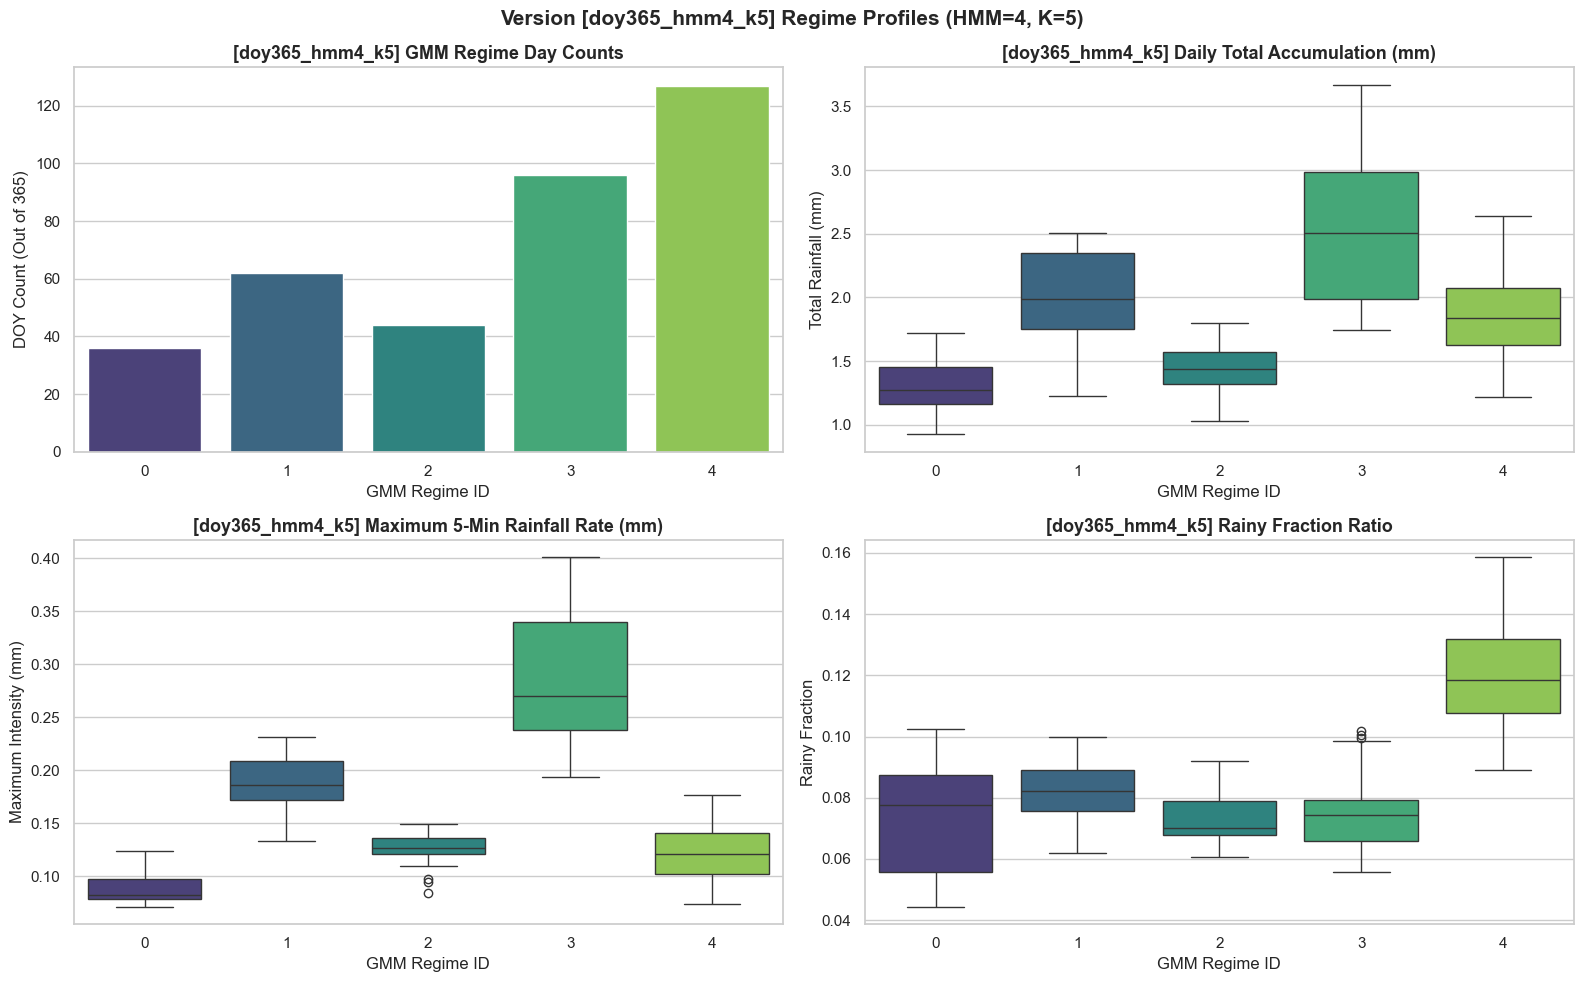

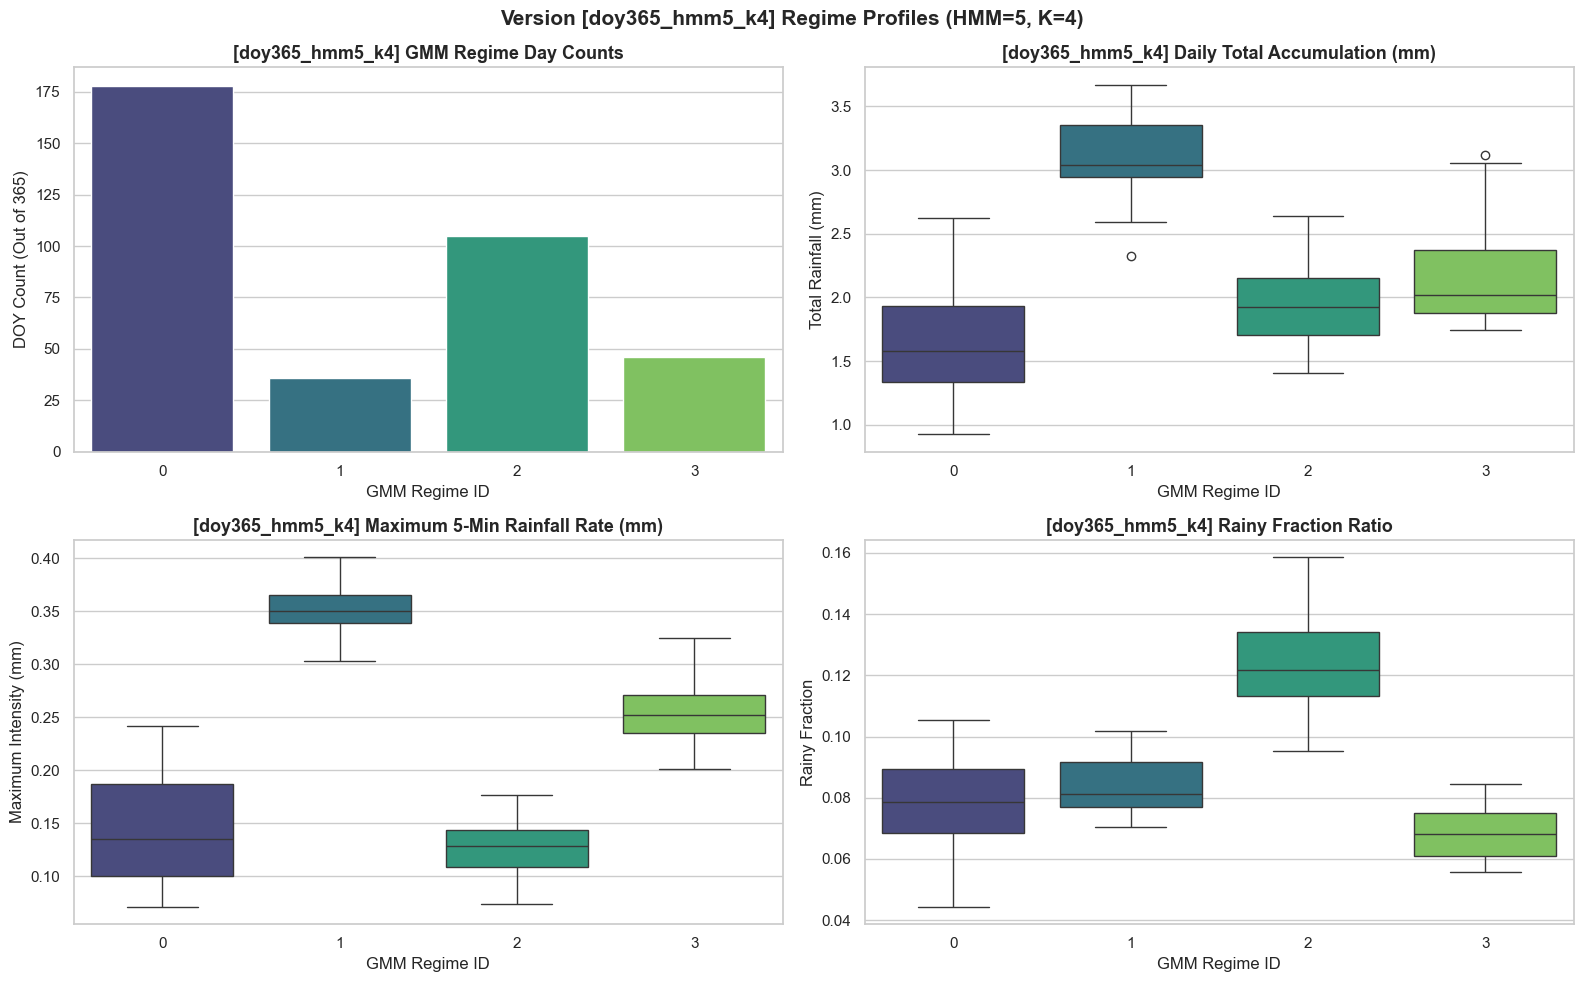

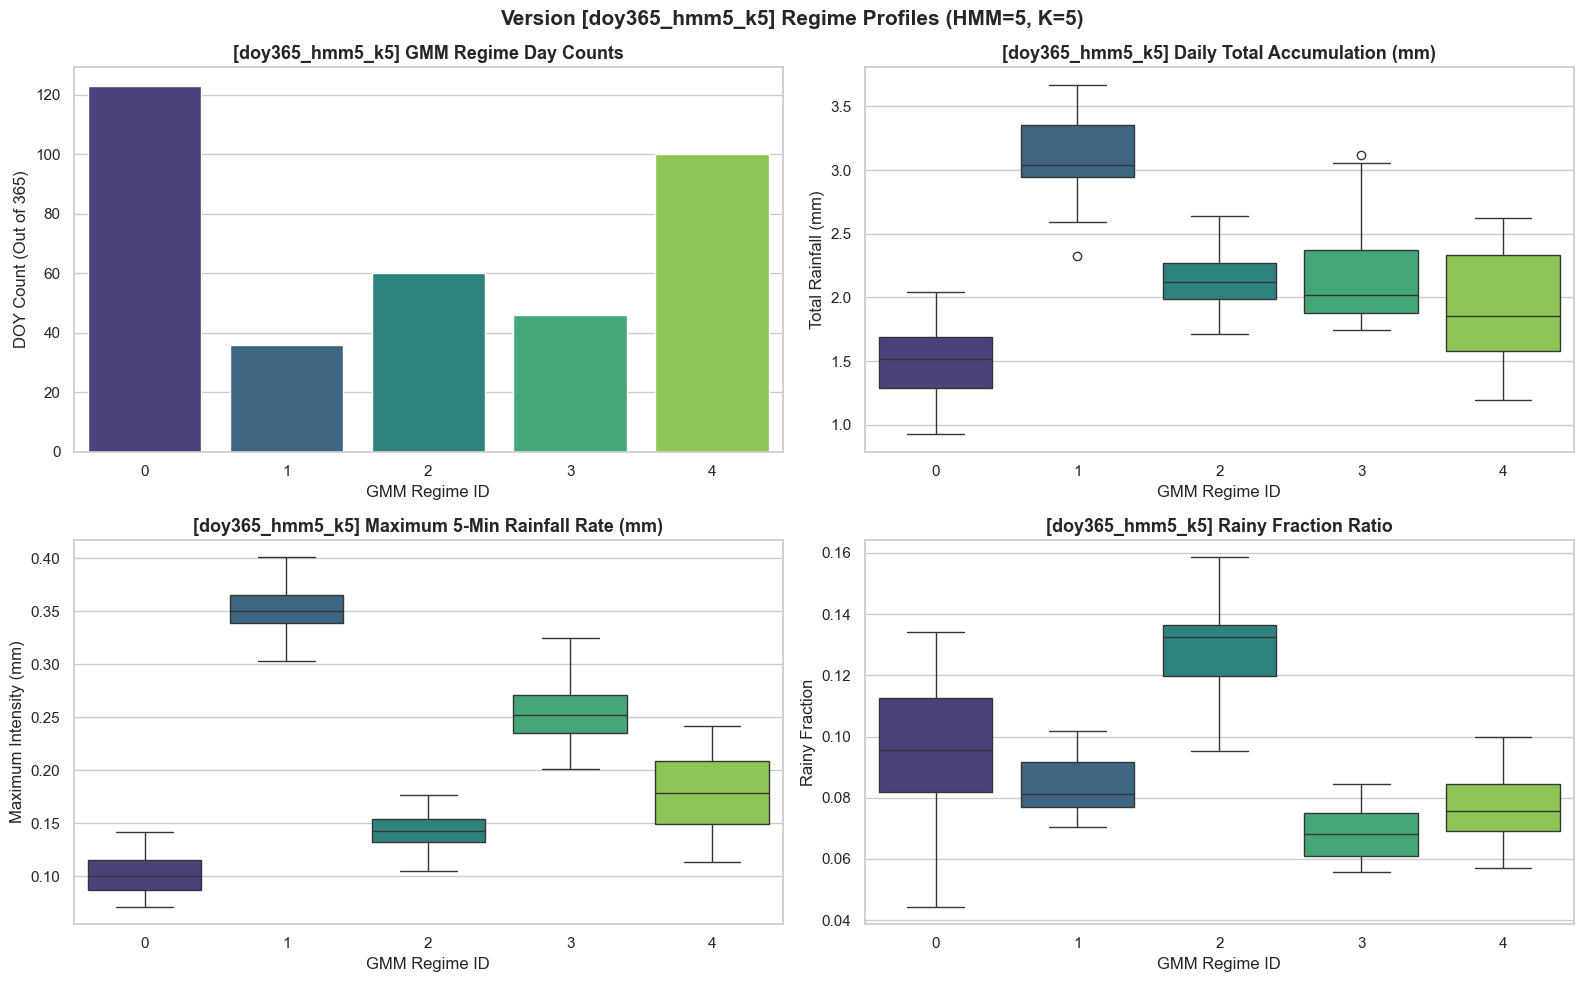

In [15]:
for prefix, h_states, g_k in experiments:
    df_p = exp_results[prefix]["df_profiles"]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Version [{prefix}] Regime Profiles (HMM={h_states}, K={g_k})", fontsize=15, fontweight="bold")
    
    sns.countplot(data=df_p, x="gmm_regime", palette="viridis", ax=axes[0, 0])
    axes[0, 0].set_title(f"[{prefix}] GMM Regime Day Counts", fontsize=13, fontweight="bold")
    axes[0, 0].set_xlabel("GMM Regime ID")
    axes[0, 0].set_ylabel("DOY Count (Out of 365)")
    
    sns.boxplot(data=df_p, x="gmm_regime", y="Total Rainfall", palette="viridis", ax=axes[0, 1])
    axes[0, 1].set_title(f"[{prefix}] Daily Total Accumulation (mm)", fontsize=13, fontweight="bold")
    axes[0, 1].set_xlabel("GMM Regime ID")
    axes[0, 1].set_ylabel("Total Rainfall (mm)")
    
    sns.boxplot(data=df_p, x="gmm_regime", y="Maximum Intensity", palette="viridis", ax=axes[1, 0])
    axes[1, 0].set_title(f"[{prefix}] Maximum 5-Min Rainfall Rate (mm)", fontsize=13, fontweight="bold")
    axes[1, 0].set_xlabel("GMM Regime ID")
    axes[1, 0].set_ylabel("Maximum Intensity (mm)")
    
    sns.boxplot(data=df_p, x="gmm_regime", y="Rainy Fraction", palette="viridis", ax=axes[1, 1])
    axes[1, 1].set_title(f"[{prefix}] Rainy Fraction Ratio", fontsize=13, fontweight="bold")
    axes[1, 1].set_xlabel("GMM Regime ID")
    axes[1, 1].set_ylabel("Rainy Fraction")
    
    plt.tight_layout()
    plt.show()


## 7. Conclusion & Dataset Version Deployment Summary

- **365-Day Climatological Clustering Pipeline**: Successfully implemented direct 365-day GMM/K-Means stratification across six version configurations in exact requested order (`doy365_nohmm_k4`, `doy365_nohmm_k5`, `doy365_hmm4_k4`, `doy365_hmm4_k5`, `doy365_hmm5_k4`, `doy365_hmm5_k5`).
- **Side-by-Side HMM vs GMM Band Visualizations**: Rendered 365-day smoothed profile comparison with HMM seasonal background bands on the left pane vs GMM regime background bands on the right pane.
- **Version-Specific Subdirectory Exports**: All datasets (`train_{version}.csv`, `val_{version}.csv`, `test_{version}.csv`, `astlingen_doy365_profiles_{version}.csv`) are exported under `../data/rainfall/astlingen/splits/365day_climatological/{version}/`.
